# Recurrent Neural Network, LSTM and GRU

Sentiment classification on the IMDB Dataset using sequential word embeddings, comparing RNN, LSTM, and GRU architectures to evaluate how different memory mechanisms affect performance on review data.

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout,LSTM,GRU

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
vocab_size = 10000
max_len = 300
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


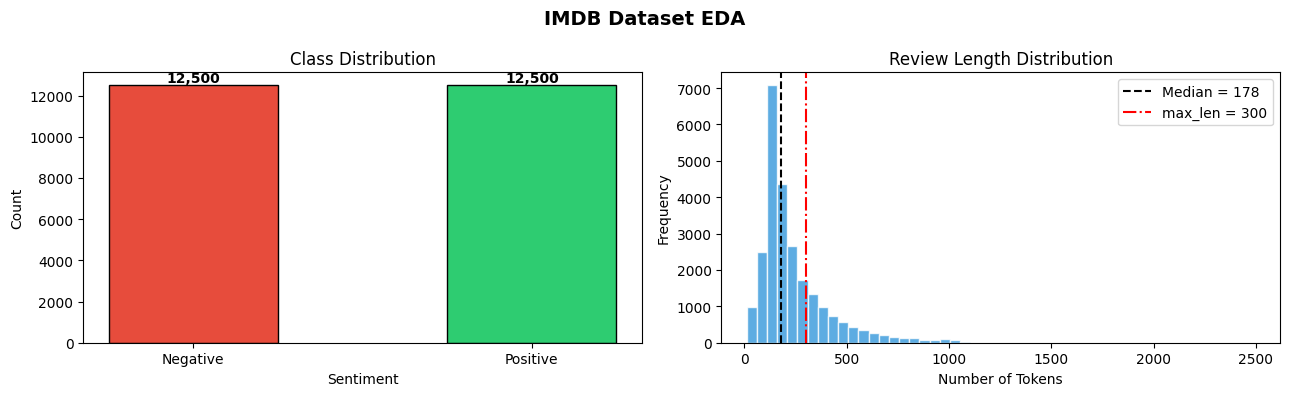

Mean length   : 238.7
Median length : 178
Max length    : 2494
Min length    : 11


In [5]:
review_lens = [len(r) for r in X_train]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('IMDB Dataset EDA', fontsize=14, fontweight='bold')

counts = [(y_train == 0).sum(), (y_train == 1).sum()]

axes[0].bar(
    ['Negative', 'Positive'],
    counts,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    width=0.5
)

axes[0].set_title('Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

for i, c in enumerate(counts):
    axes[0].annotate(
        f'{c:,}',
        (i, c),
        ha='center',
        va='bottom',
        fontweight='bold'
    )
axes[1].hist(
    review_lens,
    bins=50,
    color='#3498db',
    edgecolor='white',
    alpha=0.8
)

median_len = np.median(review_lens)

axes[1].axvline(
    median_len,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label=f'Median = {median_len:.0f}'
)

axes[1].axvline(
    max_len,
    color='red',
    linestyle='-.',
    linewidth=1.5,
    label=f'max_len = {max_len}'
)

axes[1].set_title('Review Length Distribution')
axes[1].set_xlabel('Number of Tokens')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean length   : {np.mean(review_lens):.1f}')
print(f'Median length : {np.median(review_lens):.0f}')
print(f'Max length    : {np.max(review_lens)}')
print(f'Min length    : {np.min(review_lens)}')

In [6]:
X_train = pad_sequences(X_train, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

In [15]:
def build_simple_rnn_model(vocab_size, max_len):
    model = Sequential()
    model.add(Embedding(vocab_size, 64, input_length=max_len))
    model.add(SimpleRNN(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))
    model.add(SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(learning_rate=0.0003),
        metrics=['accuracy']
    )

    return model

In [16]:
def build_lstm_model(vocab_size, max_len):
    model = Sequential()

    model.add(Embedding(vocab_size, 256, input_length=max_len))
    model.add(LSTM(64, return_sequences=True))
    model.add(Dropout(0.5))
    model.add(LSTM(32))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

In [17]:
def build_gru_model(vocab_size, max_len):
    model = Sequential()

    model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
    model.add(GRU(64))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer = Adam(learning_rate=0.0005),
        metrics=['accuracy']
    )

    return model

In [18]:
rnn_checkpoint = ModelCheckpoint(
   "best_rnn_model.h5",
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

lstm_checkpoint = ModelCheckpoint(
    "best_lstm_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

gru_checkpoint = ModelCheckpoint(
    "best_gru_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [20]:
rnn_model = build_simple_rnn_model(vocab_size, max_len)
rnn_model.summary()

rnn_model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, rnn_checkpoint],
    verbose=1
)

test_loss, test_acc = rnn_model.evaluate(X_test, y_test, verbose=0)

print(f'RNN Test Accuracy : {test_acc * 100:.2f}%')

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5038 - loss: 0.7856
Epoch 1: val_accuracy improved from None to 0.50620, saving model to best_rnn_model.h5



Epoch 1: finished saving model to best_rnn_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 92ms/step - accuracy: 0.5013 - loss: 0.7541 - val_accuracy: 0.5062 - val_loss: 0.7005
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5024 - loss: 0.7110
Epoch 2: val_accuracy improved from 0.50620 to 0.51180, saving model to best_rnn_model.h5



Epoch 2: finished saving model to best_rnn_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.5027 - loss: 0.7082 - val_accuracy: 0.5118 - val_loss: 0.6930
Epoch 3/15
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5031 - loss: 0.7039
Epoch 3: val_accuracy did not improve from 0.51180
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.4989 - loss: 0.7033 - val_accuracy: 0.5020 - val_loss: 0.6933
Epoch 4/15
156/157 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4969 - loss: 0.6995
Epoch 4: val_accuracy did not improve from 0.51180
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.4954 - loss: 0.6985 - val_accuracy: 0.4958 - val_loss: 0.6933
RNN Test Accuracy : 50.46%


In [ ]:
lstm_model = build_lstm_model(vocab_size, max_len)

lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[lstm_checkpoint, early_stop]
)

lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)
print(f"\nLSTM Test Accuracy: {lstm_acc:.4f}")


Training LSTM Model...

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.6977 - loss: 0.5341
Epoch 1: val_accuracy improved from None to 0.83360, saving model to best_lstm_model.h5



Epoch 1: finished saving model to best_lstm_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 216ms/step - accuracy: 0.7906 - loss: 0.4330 - val_accuracy: 0.8336 - val_loss: 0.3855
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9020 - loss: 0.2549
Epoch 2: val_accuracy improved from 0.83360 to 0.85120, saving model to best_lstm_model.h5



Epoch 2: finished saving model to best_lstm_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 67s 215ms/step - accuracy: 0.9006 - loss: 0.2566 - val_accuracy: 0.8512 - val_loss: 0.3502
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9258 - loss: 0.1989
Epoch 3: val_accuracy improved from 0.85120 to 0.87220, saving model to best_lstm_model.h5



Epoch 3: finished saving model to best_lstm_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 216ms/step - accuracy: 0.9323 - loss: 0.1798 - val_accuracy: 0.8722 - val_loss: 0.3239
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.9689 - loss: 0.0918
Epoch 4: val_accuracy did not improve from 0.87220
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 217ms/step - accuracy: 0.9606 - loss: 0.1109 - val_accuracy: 0.8654 - val_loss: 0.3547
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 0.9700 - loss: 0.0845
Epoch 5: val_accuracy did not improve from 0.87220
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 218ms/step - accuracy: 0.9638 - loss: 0.0996 - val_accuracy: 0.8696 - val_loss: 0.4315
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.8677 - loss: 0.3387

LSTM Test Accuracy: 0.8677


In [ ]:
gru_model = build_gru_model(vocab_size, max_len)

gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[gru_checkpoint, early_stop]
)

gru_loss, gru_acc = gru_model.evaluate(X_test, y_test)
print(f"\nGRU Test Accuracy: {gru_acc:.4f}")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.6626 - loss: 0.5806
Epoch 1: val_accuracy improved from None to 0.84440, saving model to best_gru_model.h5



Epoch 1: finished saving model to best_gru_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 114ms/step - accuracy: 0.7679 - loss: 0.4613 - val_accuracy: 0.8444 - val_loss: 0.3543
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.9053 - loss: 0.2492
Epoch 2: val_accuracy improved from 0.84440 to 0.85860, saving model to best_gru_model.h5



Epoch 2: finished saving model to best_gru_model.h5
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.8985 - loss: 0.2597 - val_accuracy: 0.8586 - val_loss: 0.3358
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.8421 - loss: 0.3578

GRU Test Accuracy: 0.8421


The RNN shows poor performance with 50.46% accuracy, indicating it is barely learning meaningful patterns due to vanishing gradient issues in long sequences. The GRU improves significantly to 84.21% accuracy, showing better handling of sequential dependencies. The LSTM performs best with 86.77% accuracy, suggesting that its gating mechanism captures long-term context more effectively for IMDB reviews.